# Análise Exploratória - Customer Support Ticket Dataset

Neste notebook, vamos realizar a análise exploratória inicial do dataset de atendimento ao cliente que será usado ao longo do projeto.

## 1. Compreensão do problema e do dataset

### Problema

Nosso projeto será um sistema de atendimento ao cliente capaz de identificar a intenção de uma mensagem. Neste primeiro TP, ainda não vamos criar o modelo de machine learning. Vamos conhecer e preparar os dados que serão usados nas próximas etapas.

### Fonte

- **Customer Support Ticket Dataset**
- https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset

### Principais características

O dataset possui informações sobre clientes, produtos e tickets de suporte. Entre as principais variáveis estão o tipo, o assunto, a descrição, o status, a prioridade e o canal do ticket. Também existem informações sobre resolução e satisfação do cliente.

### Motivo da escolha

Escolhemos esse dataset porque ele pertence ao domínio de atendimento ao cliente e possui textos e categorias que podem representar diferentes intenções dos usuários.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Inspeção inicial

Vamos verificar o tamanho do dataset, as colunas, os tipos dos dados e alguns exemplos de registros.

In [2]:
caminho_dados = "../data/customer_support_tickets.csv"
dados = pd.read_csv(caminho_dados)

print(f"O dataset possui {dados.shape[0]} registros e {dados.shape[1]} colunas.")
dados.head()

O dataset possui 8469 registros e 17 colunas.


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print("Tipos dos dados antes da preparação:\n")
dados.info()

Tipos dos dados antes da preparação:

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 

As variáveis podem ser organizadas da seguinte forma:

- **Identificação:** `Ticket ID`;
- **Cliente:** nome, e-mail, idade e gênero;
- **Compra:** produto e data da compra;
- **Ticket:** tipo, assunto, descrição, status, prioridade e canal;
- **Atendimento:** resolução, primeira resposta, tempo de resolução e satisfação.

## 3. Verificação da qualidade dos dados

Nesta etapa, vamos procurar valores ausentes, registros duplicados, tipos incorretos e problemas nos textos.

In [4]:
qualidade = pd.DataFrame({
    "valores_ausentes": dados.isna().sum(),
    "percentual": dados.isna().mean().mul(100).round(2)
})

print("Registros duplicados:", dados.duplicated().sum())
print("IDs duplicados:", dados["Ticket ID"].duplicated().sum())
display(qualidade[qualidade["valores_ausentes"] > 0])

Registros duplicados: 0
IDs duplicados: 0


,valores_ausentes,percentual
Resolution,5700,67.30
First Response Time,2819,33.29
Time to Resolution,5700,67.30
Customer Satisfaction Rating,5700,67.30


In [5]:
colunas_atendimento = [
    "Resolution",
    "First Response Time",
    "Time to Resolution",
    "Customer Satisfaction Rating",
]

ausentes_por_status = dados.groupby("Ticket Status")[colunas_atendimento].apply(
    lambda grupo: grupo.isna().sum()
)
ausentes_por_status = ausentes_por_status.rename(
    columns=lambda coluna: f"{coluna} - ausentes"
)
ausentes_por_status.insert(
    0, "Total de tickets", dados.groupby("Ticket Status").size()
)

placeholders = dados["Ticket Description"].str.contains(
    "{product_purchased}", regex=False
).sum()

print("Descrições com placeholder de produto:", placeholders)
print("\nQuantidade de valores ausentes por status do ticket:")
ausentes_por_status

Descrições com placeholder de produto: 8469

Quantidade de valores ausentes por status do ticket:


,Total de tickets,Resolution - ausentes,First Response Time - ausentes,Time to Resolution - ausentes,Customer Satisfaction Rating - ausentes
Ticket Status,,,,,
Closed,2769,0,0,0,0
Open,2819,2819,2819,2819,2819
Pending Customer Response,2881,2881,0,2881,2881


### Resultado da verificação

Não encontramos registros ou IDs duplicados. Os valores ausentes acompanham o status do atendimento: tickets abertos ou pendentes ainda não possuem resolução e satisfação. Por esse motivo, vamos manter esses valores ausentes.

Também verificamos que todas as descrições possuem o texto `{product_purchased}` no lugar do nome do produto. Vamos corrigir esse ponto durante a preparação.

## 4. Limpeza e preparação dos dados

Vamos criar uma cópia do dataset, remover espaços extras, converter as datas e substituir o placeholder pelo produto comprado. O arquivo CSV original não será alterado.

In [6]:
dados_limpos = dados.copy()

colunas_texto = dados_limpos.select_dtypes(include="str").columns
for coluna in colunas_texto:
    dados_limpos[coluna] = dados_limpos[coluna].apply(
        lambda valor: valor.strip() if isinstance(valor, str) else valor
    )

colunas_data = ["Date of Purchase", "First Response Time", "Time to Resolution"]
for coluna in colunas_data:
    dados_limpos[coluna] = pd.to_datetime(dados_limpos[coluna], errors="coerce")

dados_limpos["Ticket Description"] = dados_limpos.apply(
    lambda linha: linha["Ticket Description"].replace(
        "{product_purchased}", linha["Product Purchased"]
    ),
    axis=1,
)

In [7]:
placeholders_restantes = dados_limpos["Ticket Description"].str.contains(
    "{product_purchased}", regex=False
).sum()

print("Dimensões após a preparação:", dados_limpos.shape)
print("Placeholders restantes:", placeholders_restantes)
print("Datas de compra inválidas:", dados_limpos["Date of Purchase"].isna().sum())
print("\nTipos das colunas de data após a preparação:")
print(dados_limpos[colunas_data].dtypes)

Dimensões após a preparação: (8469, 17)
Placeholders restantes: 0
Datas de compra inválidas: 0

Tipos das colunas de data após a preparação:
Date of Purchase       datetime64[us]
First Response Time    datetime64[us]
Time to Resolution     datetime64[us]
dtype: object


## 5. Análise univariada

Vamos analisar cada variável separadamente. Para a idade, vamos observar as estatísticas e a distribuição. Para as variáveis categóricas mais relacionadas às intenções, vamos verificar as frequências.

In [8]:
estatisticas_idade = dados_limpos["Customer Age"].describe().to_frame("idade")
estatisticas_idade.loc["variancia"] = dados_limpos["Customer Age"].var()
estatisticas_idade

,idade
count,8469.000000
mean,44.026804
std,15.296112
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000
variancia,233.971058


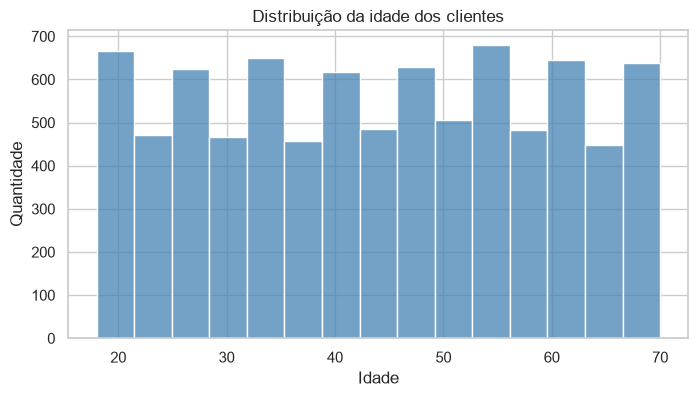

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(dados_limpos["Customer Age"], bins=15, color="steelblue")
plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.show()

In [10]:
def tabela_frequencia(coluna):
    frequencia = dados_limpos[coluna].value_counts()
    percentual = dados_limpos[coluna].value_counts(normalize=True).mul(100).round(2)
    return pd.DataFrame({"frequencia": frequencia, "percentual": percentual})

display(tabela_frequencia("Ticket Type"))
display(tabela_frequencia("Ticket Subject"))
display(tabela_frequencia("Ticket Status"))

,frequencia,percentual
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29


,frequencia,percentual
Ticket Subject,,
Refund request,576,6.80
Software bug,574,6.78
Product compatibility,567,6.70
Delivery problem,561,6.62
Hardware issue,547,6.46
Battery life,542,6.40
Network problem,539,6.36
Installation support,530,6.26
Product setup,529,6.25


,frequencia,percentual
Ticket Status,,
Pending Customer Response,2881,34.02
Open,2819,33.29
Closed,2769,32.70


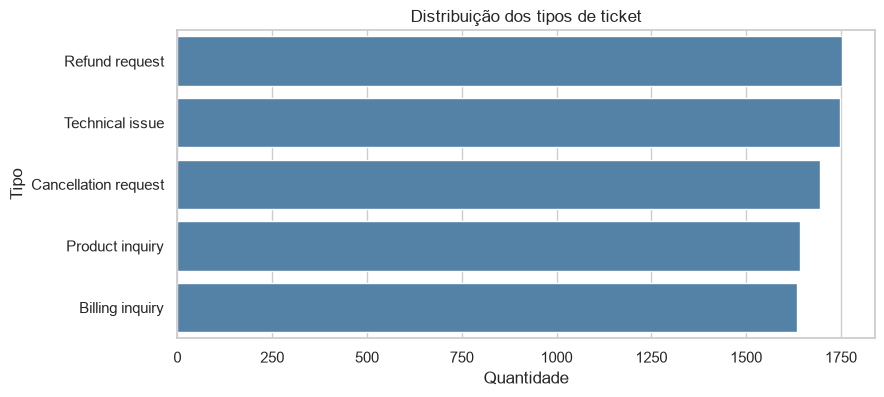

In [11]:
ordem_tipos = dados_limpos["Ticket Type"].value_counts().index

plt.figure(figsize=(9, 4))
sns.countplot(data=dados_limpos, y="Ticket Type", order=ordem_tipos, color="steelblue")
plt.title("Distribuição dos tipos de ticket")
plt.xlabel("Quantidade")
plt.ylabel("Tipo")
plt.show()

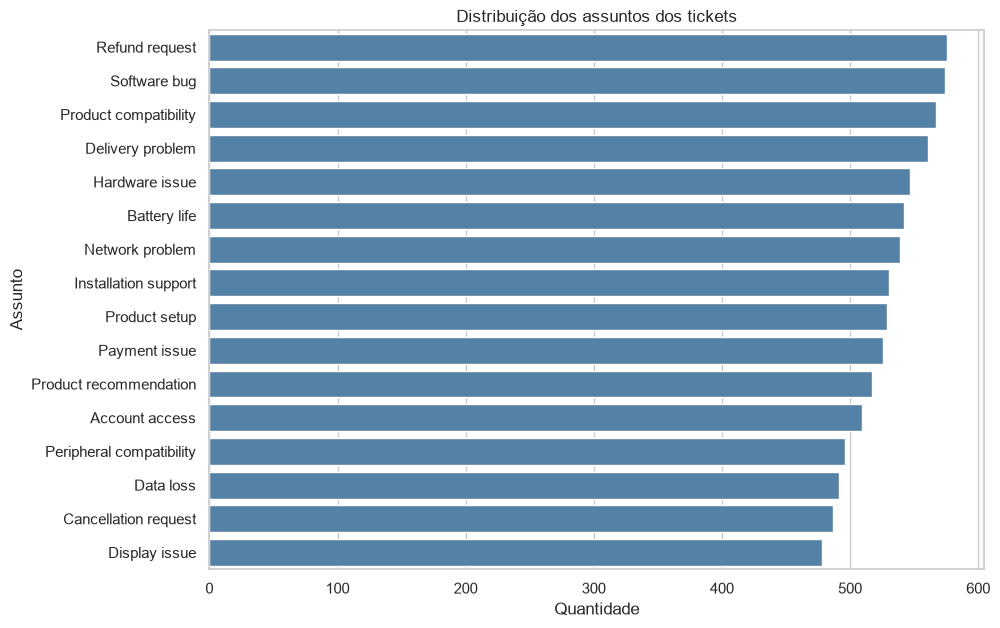

In [12]:
ordem_assuntos = dados_limpos["Ticket Subject"].value_counts().index

plt.figure(figsize=(10, 7))
sns.countplot(data=dados_limpos, y="Ticket Subject", order=ordem_assuntos, color="steelblue")
plt.title("Distribuição dos assuntos dos tickets")
plt.xlabel("Quantidade")
plt.ylabel("Assunto")
plt.show()

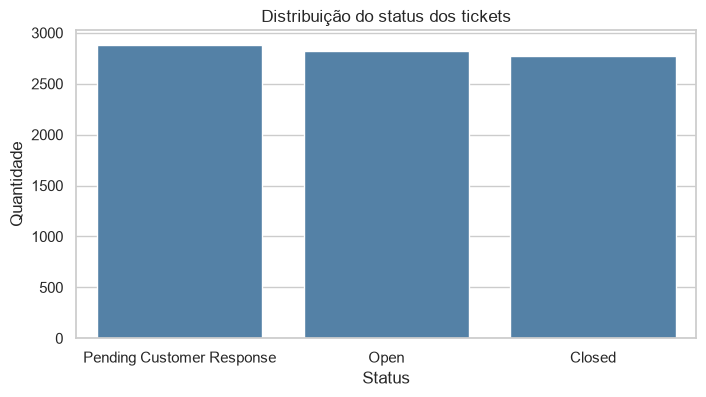

In [13]:
ordem_status = dados_limpos["Ticket Status"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=dados_limpos, x="Ticket Status", order=ordem_status, color="steelblue")
plt.title("Distribuição do status dos tickets")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()

## 6. Hipóteses sobre as intenções dos usuários

A partir das frequências e dos gráficos, levantamos três hipóteses:

1. **Desfazer uma transação:** pedidos de reembolso e cancelamento somam 3.447 tickets, cerca de 40,7% do dataset. Nossa hipótese é que uma parte importante dos usuários procura o suporte para desfazer uma compra ou cancelar um produto.
2. **Colocar o produto em funcionamento:** assuntos de configuração, instalação e compatibilidade somam 2.122 tickets, cerca de 25,1%. Nossa hipótese é que muitos usuários procuram ajuda para configurar ou utilizar corretamente o produto.
3. **Intenções variadas:** o assunto mais frequente representa apenas 6,8% dos registros. Nossa hipótese é que o atendimento precisa reconhecer várias intenções diferentes, sem uma única categoria dominante.

## 7. Conclusão

Com a análise inicial, verificamos que o dataset possui 8.469 tickets, não possui registros duplicados e apresenta categorias relativamente equilibradas. Mantivemos os valores ausentes porque eles estão relacionados ao status do atendimento e corrigimos o placeholder encontrado nas descrições.

Os padrões observados indicam intenções ligadas principalmente a reembolso, cancelamento e suporte para configuração ou uso dos produtos. Esses resultados servem como base para as próximas etapas do projeto.